In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from matplotlib.ticker import MultipleLocator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [ ]:
import sqlite3

# Connect to database
conn = sqlite3.connect("loan_risk.db")

cursor = conn.cursor()

with open("SQL/sql_queries.sql", "r") as file:
    sql_script = file.read()
    
conn.commit()

cursor.executescript(sql_script)

final_df = pd.read_sql("SELECT * FROM final_dataset", conn)

print(final_df.shape)   

(250000, 39)


In [5]:
print(final_df.columns.tolist())

['LoanID', 'CustomerID', 'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate', 'EMI', 'Loan_Purpose', 'Application_Channel', 'Age', 'Gender', 'Marital_Status', 'Number_of_Dependents', 'Education_Level', 'Employment_Status', 'Job_Type', 'Years_Employed', 'Income_Type', 'Annual_Income', 'Monthly_Income', 'Income_Stability_Score', 'Credit_Score', 'Credit_Utilization_Ratio', 'Number_of_Previous_Loans', 'Previous_Defaults', 'Delinquencies', 'Number_of_Active_Loans', 'Avg_Days_Past_Due', 'EMI_to_Income_Ratio', 'Loan_to_Income_Ratio', 'Debt_to_Income_Ratio', 'High_Risk_Flag', 'Low_Income_Flag', 'High_Loan_Flag', 'Default_Status', 'avg_monthly_spending', 'spending_to_income_ratio', 'balance_volatility', 'rent_payment_ratio', 'behavioral_risk_score']


In [6]:
# =====================================================
# 1. FEATURE SELECTION
# =====================================================

drop_cols = [
    "LoanID",
    "CustomerID",
    "Default_Status",
    "High_Risk_Flag",
    "Low_Income_Flag",
    "High_Loan_Flag"    
]

X = final_df.drop(columns=drop_cols)
y = final_df["Default_Status"]

print("Target Distribution:")
print(y.value_counts(normalize=True))


Target Distribution:
Default_Status
0    0.76896
1    0.23104
Name: proportion, dtype: float64


In [7]:
# =====================================================
# 2. ENCODE CATEGORICAL VARIABLES
# =====================================================

X = pd.get_dummies(
    X,
    drop_first=True
)

print("\nShape After Encoding:")
print(X.shape)



Shape After Encoding:
(250000, 54)


In [8]:

# =====================================================
# 3. CHECK MISSING VALUES
# =====================================================

print("\nTotal Missing Values:")
print(X.isnull().sum().sum())


Total Missing Values:
0


In [9]:
# =====================================================
# 4. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)


Train Shape: (200000, 54)
Test Shape : (50000, 54)


In [10]:
# =====================================================
# 5. FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:

# =====================================================
# 6. LOGISTIC REGRESSION
# =====================================================

lr = LogisticRegression(
    max_iter=1000, 
    random_state=42
)

lr.fit(X_train_scaled, y_train)

# =====================================================
# 7. PREDICTIONS
# =====================================================

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# =====================================================
# 8. EVALUATION
# =====================================================

lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_roc_auc = roc_auc_score(y_test, y_prob)

print("\n========== LOGISTIC REGRESSION ==========")

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"ROC AUC   : {lr_roc_auc:.4f}")





========== LOGISTIC REGRESSION ==========
Accuracy  : 0.8767
Precision : 0.7940
Recall    : 0.6297
F1 Score  : 0.7024
ROC AUC   : 0.9125


In [13]:
# =====================================================
# 9. CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     38448
           1       0.79      0.63      0.70     11552

    accuracy                           0.88     50000
   macro avg       0.84      0.79      0.81     50000
weighted avg       0.87      0.88      0.87     50000



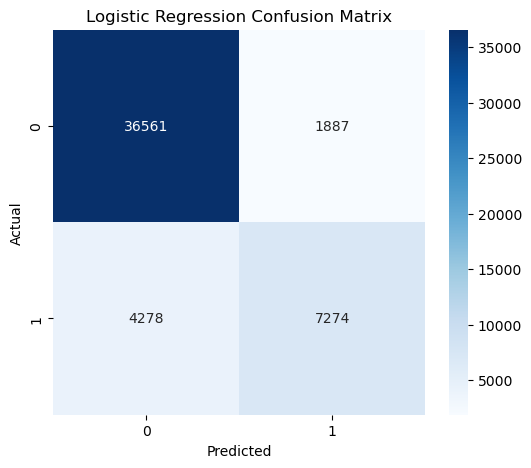

In [14]:

# =====================================================
# 10. CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Abs_Coefficient
15,Number_of_Active_Loans,1.437450,1.437450
13,Previous_Defaults,1.261567,1.261567
19,Debt_to_Income_Ratio,0.598889,0.598889
24,behavioral_risk_score,0.544974,0.544974
17,EMI_to_Income_Ratio,0.467196,0.467196
10,Credit_Score,-0.378599,0.378599
22,balance_volatility,0.090665,0.090665
7,Annual_Income,-0.060319,0.060319
8,Monthly_Income,-0.051832,0.051832
2,Interest_Rate,0.045218,0.045218


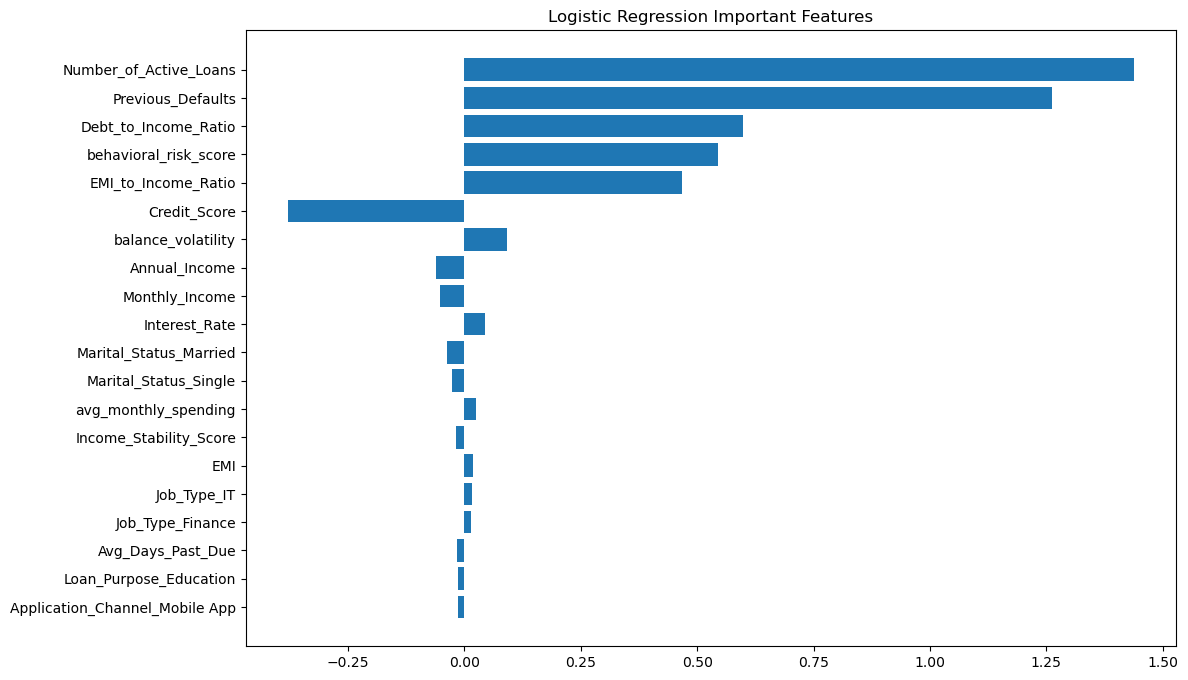

In [29]:
top20 = coef_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20["Feature"],
    top20["Coefficient"]
)

plt.title("Logistic Regression Important Features")

plt.gca().invert_yaxis()

plt.show()

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

rf_Accuracy  = accuracy_score(y_test, rf_pred)
rf_Precision = precision_score(y_test, rf_pred)
rf_Recall  = recall_score(y_test, rf_pred)
rf_F1_Score  =f1_score(y_test, rf_pred)
rf_ROC_AUC  = roc_auc_score(y_test, rf_prob)

print("========== RANDOM FOREST ==========")
print(f"Accuracy  : {rf_Accuracy:.4f}")
print(f"Precision : {rf_Precision:.4f}")
print(f"Recall    : {rf_Recall:.4f}")
print(f"F1 Score  : {rf_F1_Score:.4f}")
print(f"ROC AUC   : {rf_ROC_AUC:.4f}")

========== RANDOM FOREST ==========
Accuracy  : 0.8723
Precision : 0.8068
Recall    : 0.5882
F1 Score  : 0.6804
ROC AUC   : 0.9053


In [18]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report")
print(classification_report(y_test, rf_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     38448
           1       0.81      0.59      0.68     11552

    accuracy                           0.87     50000
   macro avg       0.85      0.77      0.80     50000
weighted avg       0.87      0.87      0.86     50000



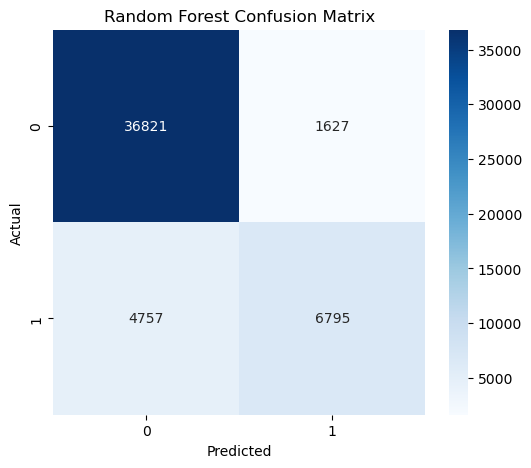

In [20]:

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
15    Number_of_Active_Loans    0.251906
19      Debt_to_Income_Ratio    0.126429
13         Previous_Defaults    0.122897
16         Avg_Days_Past_Due    0.115112
2              Interest_Rate    0.081928
17       EMI_to_Income_Ratio    0.063977
10              Credit_Score    0.058691
3                        EMI    0.021993
1           Loan_Term_Months    0.018212
24     behavioral_risk_score    0.016688
18      Loan_to_Income_Ratio    0.014656
21  spending_to_income_ratio    0.013899
20      avg_monthly_spending    0.013061
12  Number_of_Previous_Loans    0.012742
23        rent_payment_ratio    0.008451
0                Loan_Amount    0.007185
8             Monthly_Income    0.006875
22        balance_volatility    0.006871
7              Annual_Income    0.006853
14             Delinquencies    0.006299


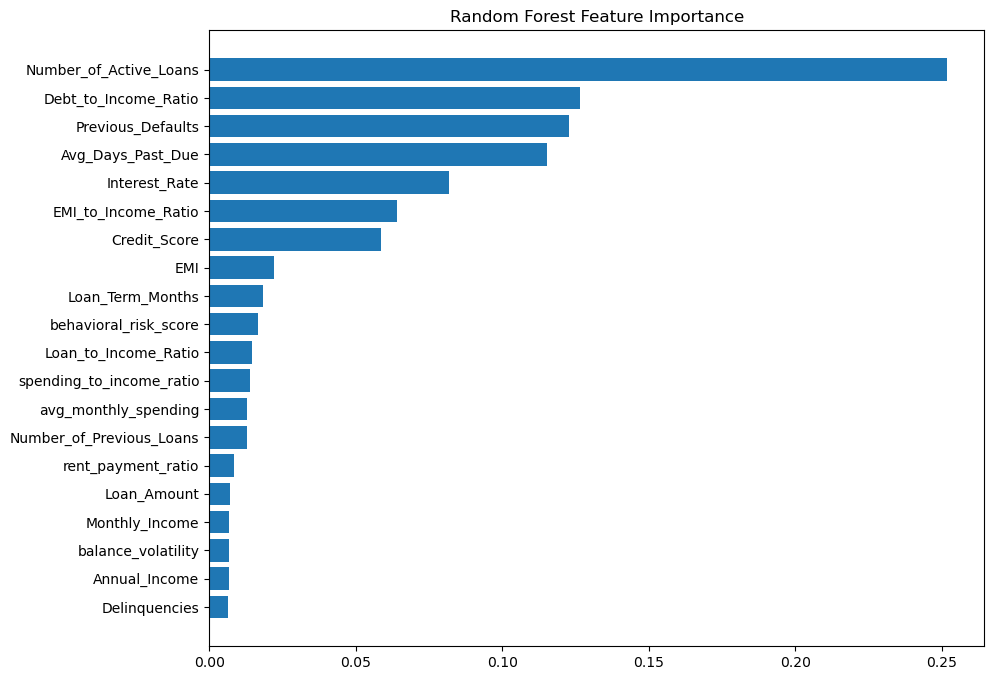

In [22]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [23]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]


xgb_Accuracy = accuracy_score(y_test, xgb_pred)
xgb_Precision = precision_score(y_test, xgb_pred)
xgb_Recall = recall_score(y_test, xgb_pred)
xgb_F1_Score = f1_score(y_test, xgb_pred)
xgb_ROC_AUC = roc_auc_score(y_test, xgb_prob)

print("========== XGBOOST ==========")
print(f"Accuracy  : {xgb_Accuracy:.4f}")
print(f"Precision : {xgb_Precision:.4f}")
print(f"Recall    : {xgb_Recall:.4f}")
print(f"F1 Score  : {xgb_F1_Score:.4f}")
print(f"ROC AUC   : {xgb_ROC_AUC:.4f}")

========== XGBOOST ==========
Accuracy  : 0.8752
Precision : 0.7875
Recall    : 0.6297
F1 Score  : 0.6998
ROC AUC   : 0.9105


In [25]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     38448
           1       0.79      0.63      0.70     11552

    accuracy                           0.88     50000
   macro avg       0.84      0.79      0.81     50000
weighted avg       0.87      0.88      0.87     50000



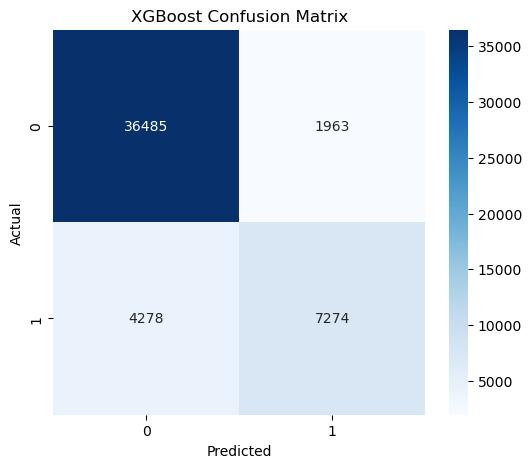

In [33]:

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
13,Previous_Defaults,0.306720
15,Number_of_Active_Loans,0.216703
19,Debt_to_Income_Ratio,0.080139
16,Avg_Days_Past_Due,0.061659
2,Interest_Rate,0.036048
17,EMI_to_Income_Ratio,0.031871
24,behavioral_risk_score,0.017296
23,rent_payment_ratio,0.014819
1,Loan_Term_Months,0.012956
10,Credit_Score,0.011826


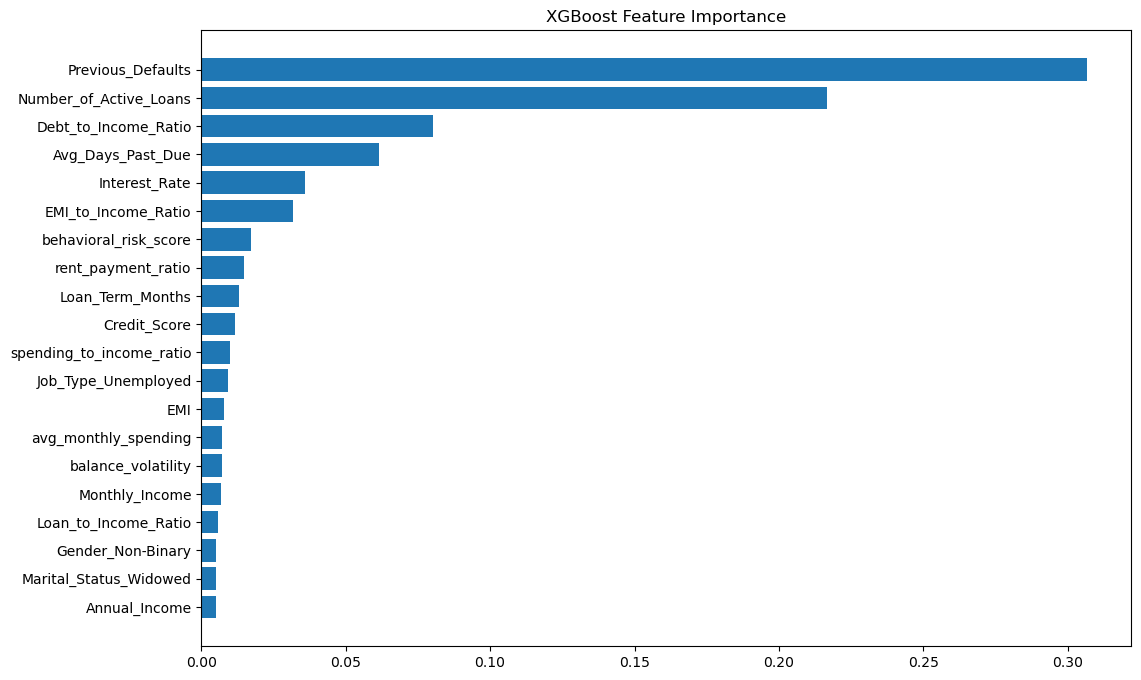

In [31]:
top20_xgb = importance.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20_xgb["Feature"],
    top20_xgb["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

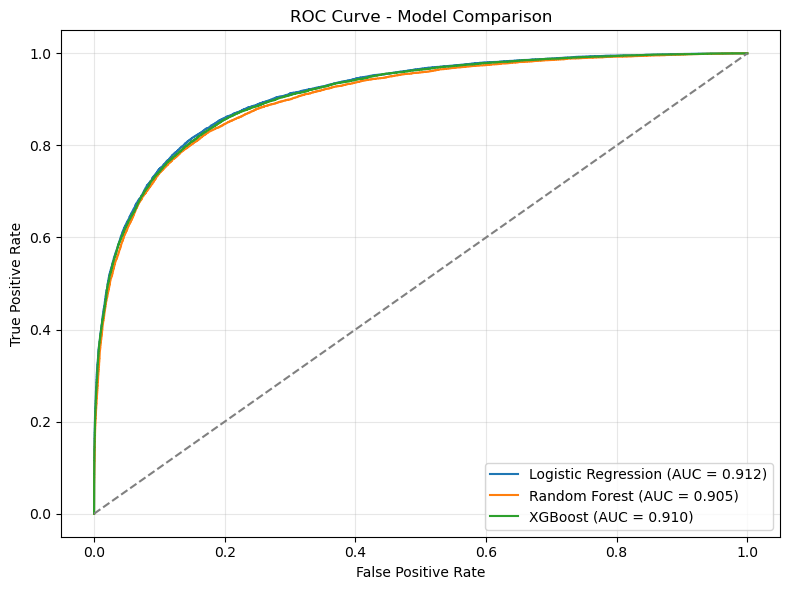

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# ======================
# Logistic Regression
# ======================
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_auc = roc_auc_score(y_test, lr_prob)

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")

# ======================
# Random Forest
# ======================
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

# ======================
# XGBoost
# ======================
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")

# ======================
# Random baseline
# ======================
plt.plot([0,1], [0,1], '--', color='gray')

# ======================
# Final formatting
# ======================
plt.title("ROC Curve - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=300)
plt.show()

,Model,Metric,Value
0,Logistic Regression,Accuracy,87.6700
1,Logistic Regression,Precision,79.4018
2,Logistic Regression,Recall,62.9675
3,Logistic Regression,F1 Score,70.2361
4,Logistic Regression,ROC AUC,91.2489
5,Random Forest,Accuracy,87.2320
6,Random Forest,Precision,80.6815
7,Random Forest,Recall,58.8210
8,Random Forest,F1 Score,68.0384
9,Random Forest,ROC AUC,90.5344


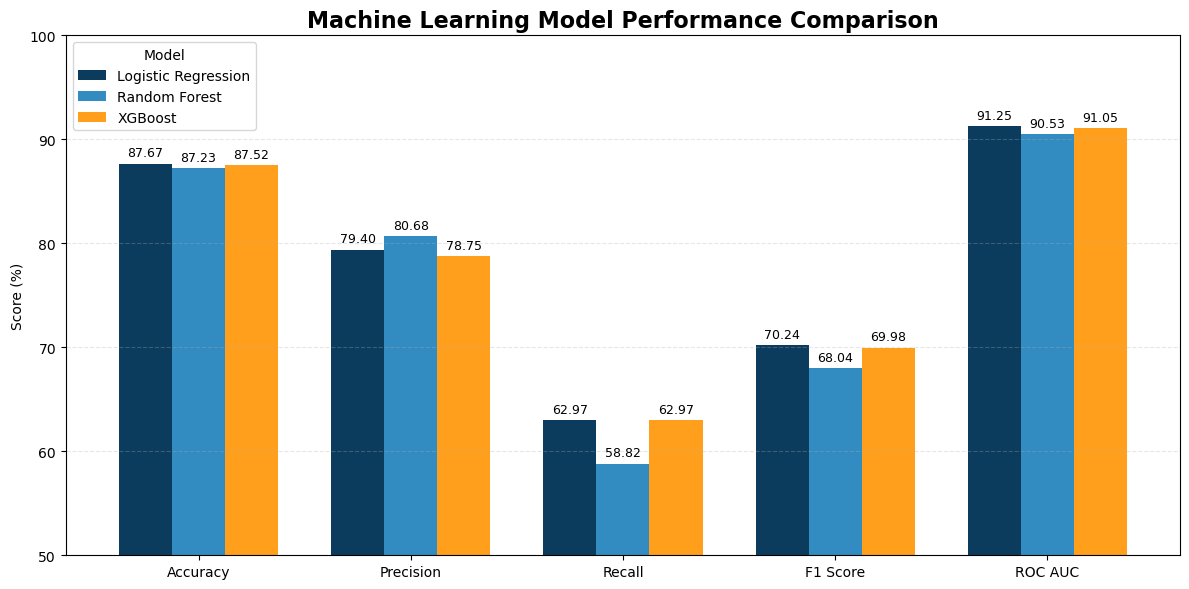

✅ model_comparison.csv saved successfully.


In [27]:
# Store metrics for each model
metrics = {
    "Logistic Regression": {
        "Accuracy": lr_accuracy,
        "Precision": lr_precision,
        "Recall": lr_recall,
        "F1 Score": lr_f1,
        "ROC AUC": lr_roc_auc
    },

    "Random Forest": {
        "Accuracy": rf_Accuracy,
        "Precision": rf_Precision,
        "Recall": rf_Recall,
        "F1 Score": rf_F1_Score,
        "ROC AUC": rf_ROC_AUC
    },

    "XGBoost": {
        "Accuracy": xgb_Accuracy,
        "Precision": xgb_Precision,
        "Recall": xgb_Recall,
        "F1 Score": xgb_F1_Score,
        "ROC AUC": xgb_ROC_AUC
    }
}

# Convert to long format
rows = []

for model, values in metrics.items():
    for metric, value in values.items():

        # Convert everything except ROC AUC to %
        value = round(value * 100, 4)

        rows.append([model, metric, value])

model_comparison = pd.DataFrame(
    rows,
    columns=["Model", "Metric", "Value"]
)

display(model_comparison)



plot_df = model_comparison.pivot(
    index="Metric",
    columns="Model",
    values="Value"
)

# Desired order
plot_df = plot_df.loc[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
]

# Plot
ax = plot_df.plot(
    kind="bar",
    figsize=(12,6),
    width=0.75,
    color=["#0B3C5D", "#328CC1", "#FF9F1C"]
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Score (%)")

plt.ylim(50,100)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(title="Model")

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=9,
        padding=3
    )

plt.tight_layout()
plt.show()



# Save CSV
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("✅ model_comparison.csv saved successfully.")

In [38]:
coef_df.to_csv(
    "coefficient.csv",
    index=False
)


In [39]:
print(lr.coef_.shape)
print(lr.coef_[0][:10])

(1, 54)
[-0.00593741 -0.00390951  0.04521757  0.01787032  0.00364074  0.00498278
  0.00263831 -0.06031907 -0.051832   -0.01874447]


### SHAP AI


Creating SHAP Explainer...
Calculating SHAP Values...
Done!


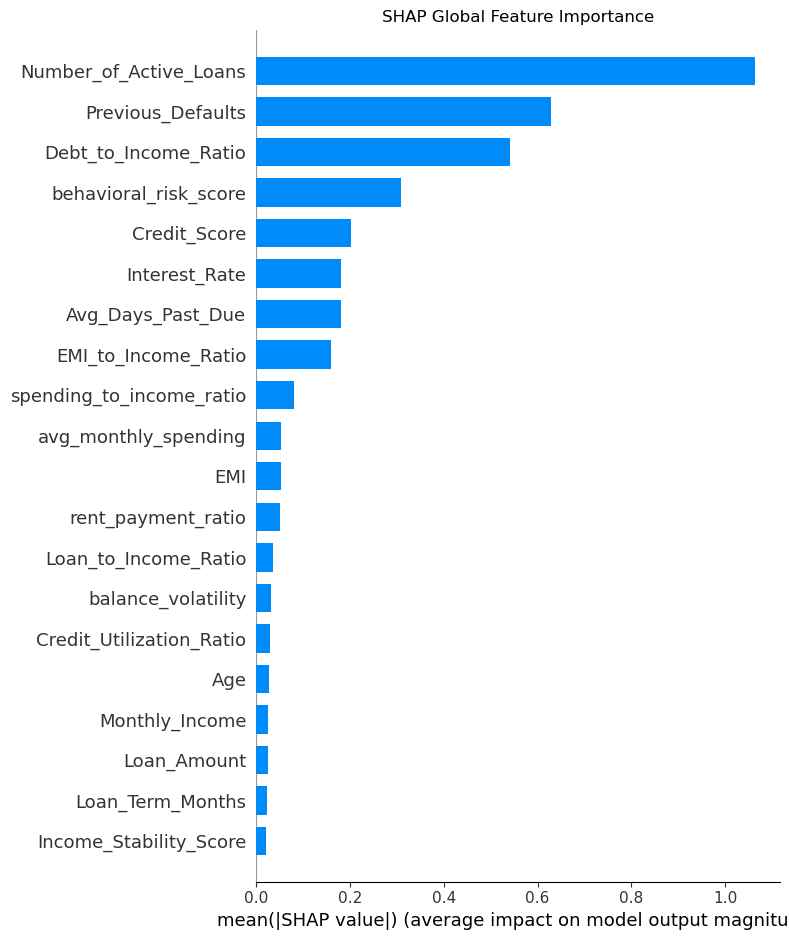

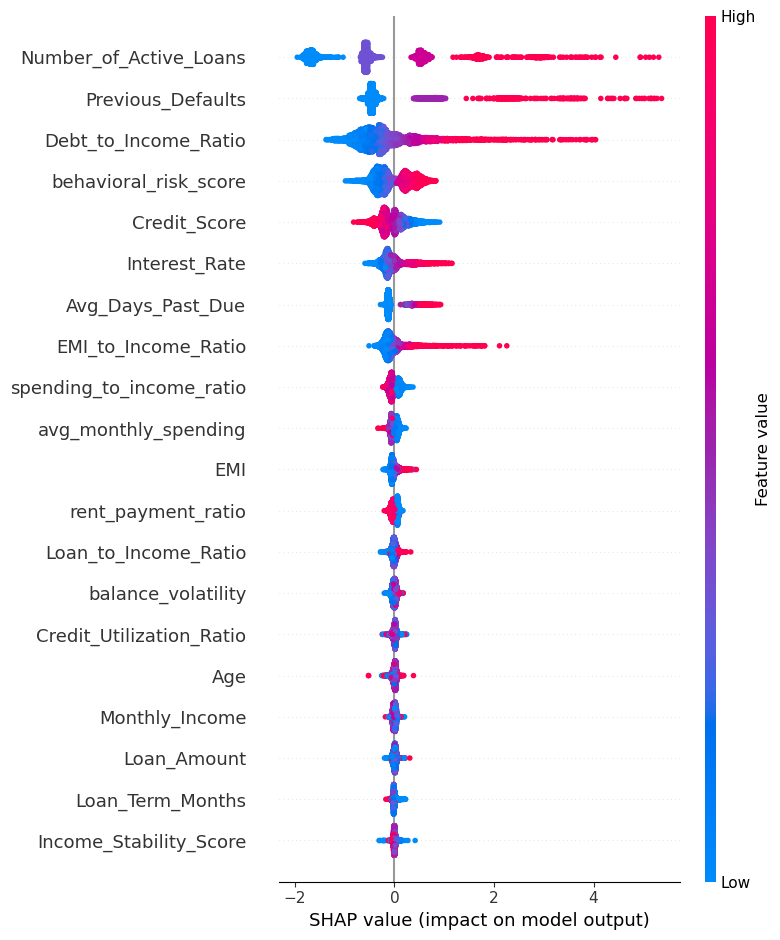


Top 10 SHAP Features:



,Feature,Mean_SHAP_Impact
15,Number_of_Active_Loans,1.063674
13,Previous_Defaults,0.629453
19,Debt_to_Income_Ratio,0.540832
24,behavioral_risk_score,0.308329
10,Credit_Score,0.201700
2,Interest_Rate,0.181029
16,Avg_Days_Past_Due,0.180926
17,EMI_to_Income_Ratio,0.159099
21,spending_to_income_ratio,0.079909
20,avg_monthly_spending,0.054094



Generating explanation for one customer...



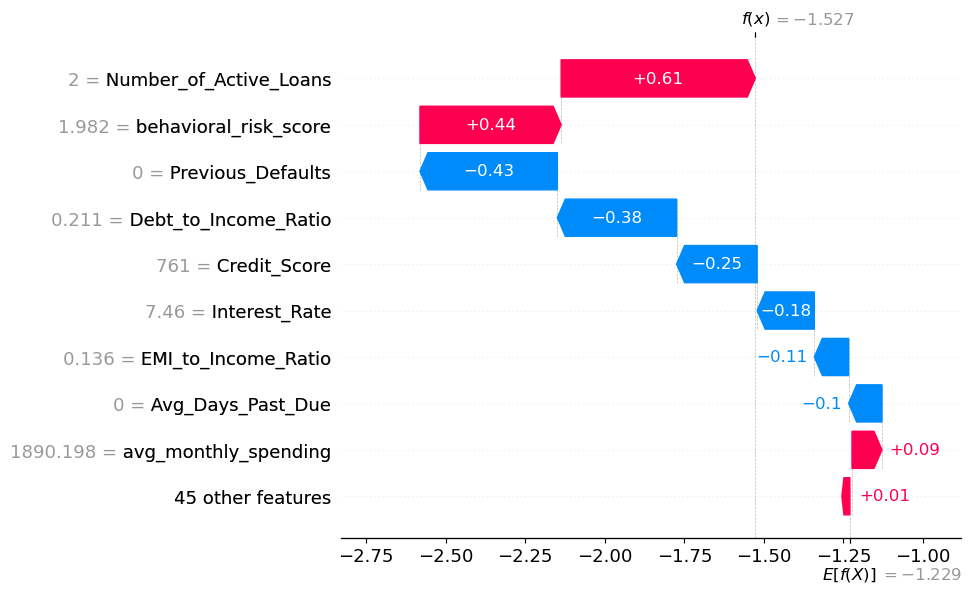


✅ SHAP feature importance saved.


In [35]:
# =====================================================
# SHAP EXPLAINABILITY
# =====================================================

print("Creating SHAP Explainer...")

explainer = shap.TreeExplainer(xgb)

# For speed, use a sample instead of entire test set
X_sample = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=42
)

print("Calculating SHAP Values...")

shap_values = explainer.shap_values(X_sample)

print("Done!")

# =====================================================
# 1. SHAP BAR PLOT (GLOBAL IMPORTANCE)
# =====================================================

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)

plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

# =====================================================
# 2. SHAP BEESWARM PLOT
# =====================================================

shap.summary_plot(
    shap_values,
    X_sample
)

# =====================================================
# 3. NUMERICAL FEATURE IMPORTANCE TABLE
# =====================================================

shap_importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean_SHAP_Impact": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_SHAP_Impact",
    ascending=False
).head(10)

print("\nTop 10 SHAP Features:\n")

display(shap_importance)

# =====================================================
# 4. SINGLE CUSTOMER EXPLANATION
# =====================================================

customer_idx = 0

print("\nGenerating explanation for one customer...\n")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[customer_idx],
        feature_names=X_sample.columns
    )
)

# =====================================================
# 5. SAVE FEATURE IMPORTANCE
# =====================================================

shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("\n✅ SHAP feature importance saved.")

In [36]:
shap_importance.to_csv(
    "enterprise_database/shap_importance.csv",
    index=False
)

print("Saved!")

Saved!
